In [1]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
plt.style.use(['science','no-latex'])
import json

### Raw data processing

In [2]:
for num in range(1,3):
    tweets = []
    with open(f'base_{num}.json', 'r') as file:
        # One trainning trail
        for line in file:
            tweets.append(json.loads(line))
        index = []
        reward = []
        for tweet in tweets:
            index.append(tweet['num_env_steps_sampled'])
            reward.append(tweet['episode_reward_mean']) 
        index = np.array(index)
        reward = np.array(reward)
    np.save(f'base_Index_{num}.npy',index)
    np.save(f'base_Reward_{num}.npy',reward)
    print('Finished: Trail '+str(num))

Finished: Trail 1
Finished: Trail 2


In [34]:
for num in range(1,3):
    tweets = []
    with open(f'aug_{num}.json', 'r') as file:
        # One trainning trail
        for line in file:
            tweets.append(json.loads(line))
        index = []
        reward = []
        for tweet in tweets:
            index.append(tweet['num_env_steps_sampled'])
            reward.append(tweet['episode_reward_mean']) 
        index = np.array(index)
        reward = np.array(reward)
    np.save(f'aug_Index_{num}.npy',index)
    np.save(f'aug_Reward_{num}.npy',reward)
    print('Finished: Trail '+str(num))

Finished: Trail 1
Finished: Trail 2


### Mean and std

In [35]:
index1 = np.load('base_Index_1.npy')
index2 = np.load('base_Index_2.npy')
print(index1.shape[0])
print(index2.shape[0])
min_length = min(index1.shape[0], index2.shape[0])

index1 = np.load('base_Index_1.npy')[:min_length]
index2 = np.load('base_Index_2.npy')[:min_length]
reward1 = np.load('base_Reward_1.npy')[:min_length]
reward2 = np.load('base_Reward_2.npy')[:min_length]
# index3 = np.load('Index_3.npy')
# reward3 = np.load('Reward_3.npy')
reward = np.vstack((reward1,reward2))
print(reward.shape)


1303
1431
(2, 1303)


In [36]:
mean_reward = np.average(reward, axis=0)
std_reward = np.std(reward, axis=0)
print(mean_reward.shape)

(1303,)


In [41]:
aug_index1 = np.load('aug_Index_1.npy')[:min_length]
aug_index2 = np.load('aug_Index_2.npy')[:min_length]
aug_reward1 = np.load('aug_Reward_1.npy')[:min_length]
aug_reward2 = np.load('aug_Reward_2.npy')[:min_length]
aug_reward = np.vstack((aug_reward1,aug_reward2))
print(aug_reward.shape)
aug_mean_reward = np.average(aug_reward, axis=0)
aug_std_reward = np.std(aug_reward, axis=0)
print(aug_mean_reward.shape)

(2, 1303)
(1303,)


(2, 2724)
(2724,)


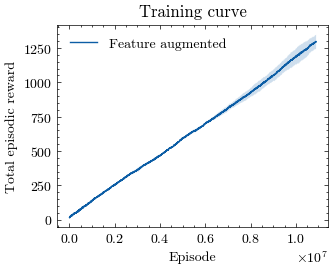

In [50]:
aug_index1 = np.load('aug_Index_1.npy')[:2724]
aug_index2 = np.load('aug_Index_2.npy')[:2724]
aug_reward1 = np.load('aug_Reward_1.npy')[:2724]
aug_reward2 = np.load('aug_Reward_2.npy')[:2724]
aug_reward = np.vstack((aug_reward1,aug_reward2))
print(aug_reward.shape)
aug_mean_reward = np.average(aug_reward, axis=0)
aug_std_reward = np.std(aug_reward, axis=0)
print(aug_mean_reward.shape)
plt.plot(aug_index1, aug_mean_reward, label='Feature augmented')
plt.fill_between(aug_index1, aug_mean_reward+aug_std_reward, aug_mean_reward-aug_std_reward, alpha=0.2)
plt.title('Training curve')
plt.xlabel('Episode')
plt.ylabel('Total episodic reward')
plt.legend()

### Result plot

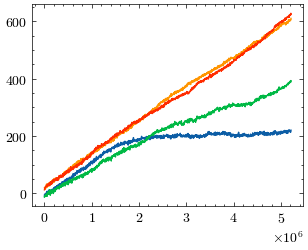

In [42]:
plt.plot(index1, reward1)
plt.plot(index1, reward2)
plt.plot(index1, aug_reward1)
plt.plot(index1, aug_reward2)


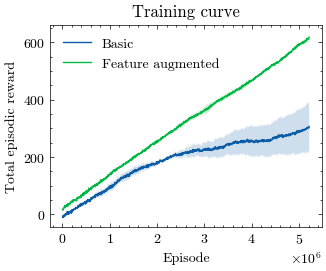

In [45]:
smooth = 1
max_reward = mean_reward + std_reward
min_reward = mean_reward - std_reward

aug_max_reward = aug_mean_reward + aug_std_reward
aug_min_reward = aug_mean_reward - aug_std_reward

plt.plot(index1[::smooth], mean_reward[::smooth], label='Basic')
plt.fill_between(index1, max_reward, min_reward, alpha=0.2)
plt.plot(index1[::smooth], aug_mean_reward[::smooth], label='Feature augmented')
plt.fill_between(index1, aug_max_reward, aug_min_reward, alpha=0.2)
plt.title('Training curve')
plt.xlabel('Episode')
plt.ylabel('Total episodic reward')
plt.legend()
plt.savefig('base_Training', dpi=300)


In [ ]:
index1 = np.load('base_Index_1.npy')
index2 = np.load('base_Index_2.npy')
print(index1.shape[0])
print(index2.shape[0])
min_length = min(index1.shape[0], index2.shape[0])

index1 = np.load('base_Index_1.npy')[:min_length]
index2 = np.load('base_Index_2.npy')[:min_length]
reward1 = np.load('base_Reward_1.npy')[:min_length]
reward2 = np.load('base_Reward_2.npy')[:min_length]
# index3 = np.load('Index_3.npy')
# reward3 = np.load('Reward_3.npy')
reward = np.vstack((reward1,reward2))
print(reward.shape)
